# Animal Species Classification - 01: EDA

Classify animals into 6 species (bird, cat, deer, dog, frog, horse). The data is the animal subset of **CIFAR-10**: tiny 32x32 real-world photos, upsampled here. We ship a committed 64x64 sample under `data/sample/<animal>/`. This is deliberately harder than the Fruit project: low resolution, cluttered backgrounds, varied poses.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
imgs, labels, classes = utils.load_sample()
print('classes:', classes)
print('total images:', len(imgs))

classes: ['bird', 'cat', 'deer', 'dog', 'frog', 'horse']
total images: 2100


## 1. Class balance

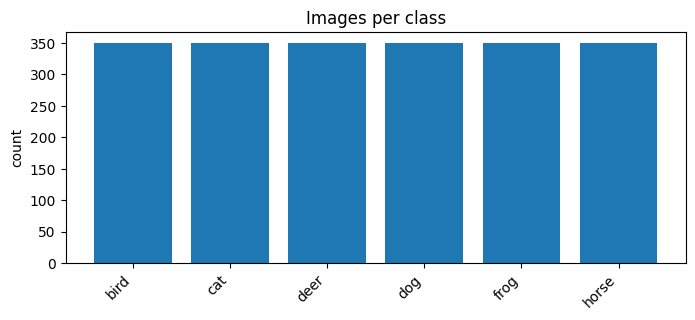

bird           350
cat            350
deer           350
dog            350
frog           350
horse          350


In [2]:
import collections
cnt = collections.Counter(labels)
plt.figure(figsize=(8,3)); plt.bar(list(cnt.keys()), list(cnt.values()))
plt.xticks(rotation=45, ha='right'); plt.ylabel('count'); plt.title('Images per class'); plt.show()
for k in classes: print('%-14s %d' % (k, cnt[k]))

## 2. One sample per class

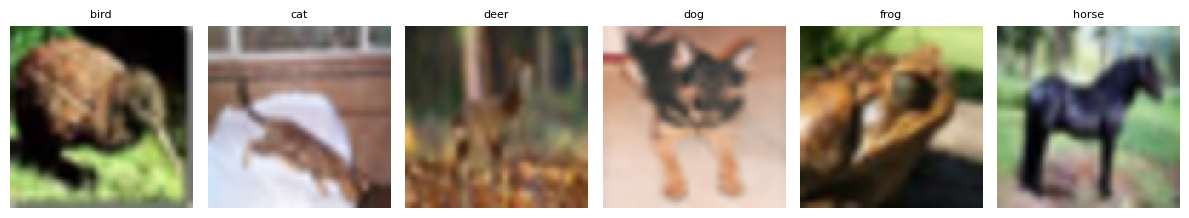

In [3]:
fig, ax = plt.subplots(1, len(classes), figsize=(2*len(classes), 2.4))
seen=set()
for im,l in zip(imgs,labels):
    if l in seen: continue
    seen.add(l); a=ax[classes.index(l)]; a.imshow(im); a.set_title(l, fontsize=8); a.axis('off')
plt.tight_layout(); plt.show()

## 3. A grid from one class

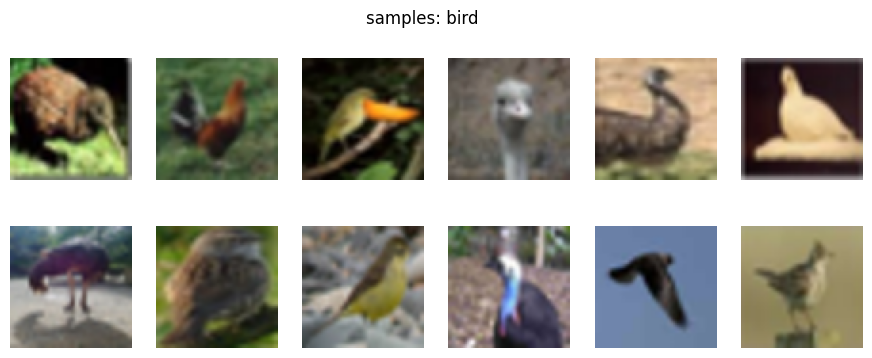

In [4]:
target = classes[0]
sel = [im for im,l in zip(imgs,labels) if l==target][:12]
fig, ax = plt.subplots(2,6, figsize=(11,4))
for a,im in zip(ax.ravel(), sel): a.imshow(im); a.axis('off')
plt.suptitle('samples: '+target); plt.show()

### Findings
Unlike the clean fruit photos, these are low-resolution snapshots with busy backgrounds and animals in many poses. Cat vs dog and deer vs horse are genuinely confusable even for people at 32x32.